#SWIGGY SALES ANALYSIS

####import libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
!pip install openpyxl

####Import Data

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("swiggy_data.xlsx")


Saving swiggy_data.xlsx to swiggy_data.xlsx


In [ ]:
df.head() #first 5 rows

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [ ]:
df.tail() #last 5 rows

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


####MetaData


In [ ]:
print("Number of Rows :",df.shape[0])

Number of Rows : 197430


In [ ]:
print("Number of columns :",df.shape[1])

Number of columns : 10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


####DataTypes

In [ ]:
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


In [ ]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


###KPI'S

####Total sales

In [ ]:
total_sales = df["Price (INR)"].sum()
print("Total sales (INR)",round(total_sales,2))

Total sales (INR) 53012505.77


####Average Rating

In [ ]:
average_rating = df["Rating"].mean()
print("Average Rating :",round(average_rating,2))

Average Rating : 4.34


####Average order value

In [ ]:
avg_order_val = df["Price (INR)"].mean()
print("avg_order_val (INR)",round(avg_order_val,2))

avg_order_val (INR) 268.51


####Rating Count

In [ ]:
rating_count = df["Rating Count"].sum()
print("Rating count :",round(rating_count,2))

Rating count : 5591574


####Total Orders

In [ ]:
total_order = df["Order Date"].count()
print("total_order :",round(total_order,2))
# total_order = len(df)
# print("total_order :",round(total_order,2))

total_order : 197430


#CHARTS DESIGN

Monthly Sales Trend

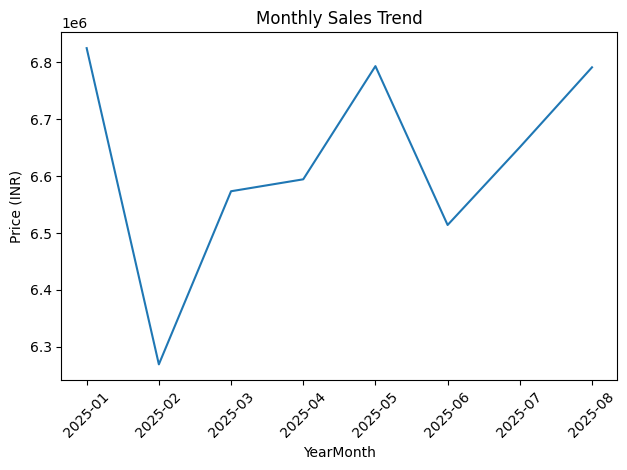

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_sales ["YearMonth"] , monthly_sales ["Price (INR)"])
plt.xticks(rotation = 45)
plt.xlabel("YearMonth")
plt.ylabel("Price (INR)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()


Total sales by food type (Veg vs Non-veg)

Daily sales trend

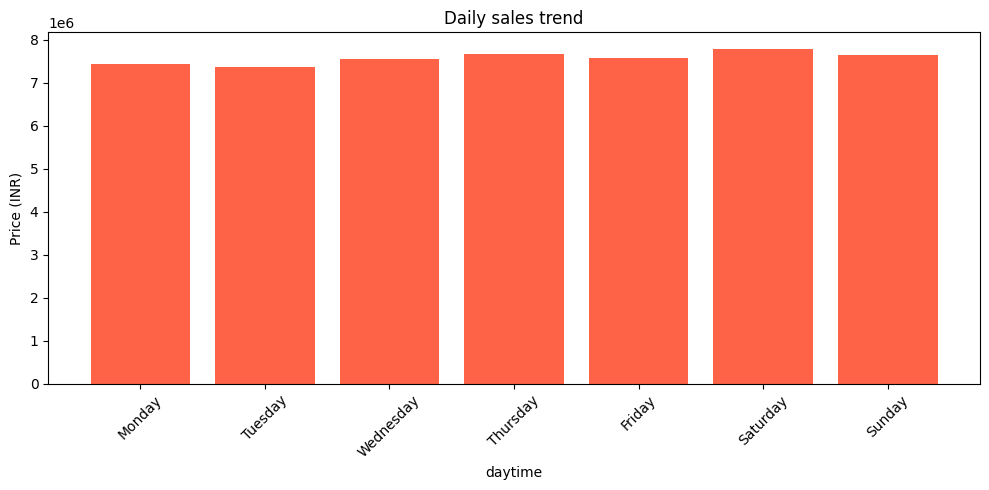

In [ ]:
df["daytime"] = pd.to_datetime(df["Order Date"]).dt.day_name()
daily_revenue = (
    df.groupby("daytime")["Price (INR)"].sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index , daily_revenue.values , color = "tomato")
plt.xticks(rotation = 45)
plt.xlabel("daytime")
plt.ylabel("Price (INR)")
plt.title("Daily sales trend")
plt.tight_layout()
plt.show()



Total sales by food type (Veg vs Non-veg)

In [ ]:
from numpy.random.mtrand import f
non_veg_keyword = [
    "chicken", "egg","fish", "mutton","kebab"
    "prawn", "biryani","kabab", "non-veg", "non veg"
]
df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keyword), na = False),
    "Non-veg",
    "veg"
)

In [ ]:
food_revenue =( df.groupby("Food Category")["Price (INR)"].sum().reset_index())


In [ ]:
fig = px.pie(
    food_revenue,
    values = "Price (INR)",
    names = "Food Category",
    hole = 0.5,
    title = "Revenue Contribution : Veg vs Non-Veg",
)
fig.update_traces(
    textposition = "inside" , textinfo = "percent+label" , pull = [0.05,0])

fig.update_layout(
    height =500,
    margin = dict(t=40, l=40, r=40, b=40),
   )
fig.show()

Total sales by States

In [ ]:
fig = px.bar(
   df.groupby("State", as_index = False)["Price (INR)"].sum()
   .sort_values("Price (INR)" , ascending=False),
   x="Price (INR)",
   y= "State",
   orientation = "h",
   title = "Revenue By State (INR)"
)

fig.update_layout(
    height = 500,
    yaxis = dict(autorange = "reversed")),

fig.show()

Quartely Performance Summary

In [ ]:
df["Order Date"]=  pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index = False)
    .agg(
         total_sales =("Price (INR)", "sum"),
         average_rating = ("Rating","mean"),
         total_order= ("Order Date", "count")
     ).sort_values("Quarter")
)
quarterly_summary["total_sales"] = quarterly_summary["total_sales"].round(0)
quarterly_summary["average_rating"] = quarterly_summary["average_rating"].round(2)

quarterly_summary

,Quarter,total_sales,average_rating,total_order
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


TOP 5 Cities By Sales

In [ ]:
top5_cities = (
    df.groupby("City")["Price (INR)"].sum().nlargest(5)
    .sort_values().reset_index()
)
fig = px.bar(
    top5_cities,
    x = "Price (INR)",
    y = "City",
    orientation = "h",
    title = "Top 5 Cities By Sales (INR)",
    color_discrete_sequence = ["red"]
)
fig.show()